# P(k) + B(k) without a cosmological model: the linear spectrum, the growth rate, and $\Lambda$CDM

**What this is.** A Fisher forecast for a DESI-Y6-like mock, comparing what the power spectrum
alone measures with what the power spectrum plus the tree-level bispectrum measure — in a model
where the linear power spectrum is *not* assumed to be $\Lambda$CDM.

**The model.** Instead of a cosmology, the linear spectrum is a free function on a grid,
$$P_{\rm lin}(k) = a(k)\,T(k),$$
with $T$ a fixed fiducial template (CosmoPower, Mpc$^3$, $z_{\rm ref}=5$, the 80 emulator knots)
and $\ln a$ free on 60 nodes, cubic-splined in $\ln k$. Alongside it sit the growth and geometry
parameters, free at every redshift: $f$, $H/H_0$, $D_A H_0$, the growth ratios $D(z)/D(z_{\rm ref})$,
and $h_{\rm conv}$ (the Mpc$/h$ ruler). Every EFT coefficient is free per sky. This is exactly the
model our HMC samples (`mi_model.py` + `setups.COMMON`), including its priors, so the Fisher here
can be checked against a real chain — it reproduces the chain's per-node widths to 5%.

**Three results, one covariance matrix.** Sections 4–6 are three different linear functionals of
the same inverse Fisher: the spectrum itself, the growth sector, and — composing with the
cosmology map — $\Lambda$CDM.

The AP / BAO parameters get their own notebook, `09_bao_pk_bk.ipynb`.

## 1. The mock data

Seven sky patches over six effective redshifts, DESI-Y6-like volumes and number densities. The
data vector is **noiseless**: it is the model evaluated at the fiducial cosmology, so the Fisher
is evaluated at the truth and no realization noise enters. Covariance is Gaussian and analytic
(`utils_cov.get_cov_gauss` for P, `get_cov_b_PPP` for B); no window, no binning effects, and zero
P–B cross-covariance.

* **P(k)**: monopole, quadrupole **and hexadecapole**, $0.01 < k < 0.2\ h/$Mpc, $\Delta k = 0.01$.
* **B(k)**: tree-level monopole on closed triangles, $0.02 < k < 0.10\ h/$Mpc.

The *same* P(k) configuration is used in both likelihoods, so every width ratio below is
attributable to the bispectrum alone.

In [1]:
import os, sys
os.chdir(os.path.dirname(os.path.abspath('.')) if os.path.basename(os.getcwd()) != 'fisher'
         else os.getcwd())
sys.path.insert(0, os.getcwd())
import numpy as np
R = np.load('../../output/fisher_pb/jacobians_pb.npz', allow_pickle=True)
print(f"redshift bins: {np.round(R['zeff_unique'], 3).tolist()}   ({int(R['num_skies'])} skies, "
      f"sky -> z index {R['sky_to_z_idx'].tolist()})")
print(f"free parameters per data set: {R['J_p'].shape[1]} (P)   {R['J_pb'].shape[1]} (P+B)")
print(f"   = per-sky EFT ({len(R['eft_names_p'])} P / {len(R['eft_names_pb'])} P+B names x "
      f"{int(R['num_skies'])} skies) + {int(R['n_knots'])} template amplitudes + "
      f"{int(R['n_growth'])} growth/geometry")
print(f"data vector: {R['J_p'].shape[0]} bins (P0,P2,P4)   {R['J_pb'].shape[0]} bins (+B0: "
      f"{int(R['isB_pb'].sum())} triangles)")
print(f"exact-symmetry check, delta chi^2 along g1/g2/g3 for a 1% move "
      f"(0 = exact): {np.round(R['sym_tests_pb'][0][:3], 4).tolist()}")

redshift bins: [0.295, 0.51, 0.706, 0.93, 1.317, 1.491]   (7 skies, sky -> z index [0, 1, 2, 3, 3, 4, 5])
free parameters per data set: 203 (P)   217 (P+B)
   = per-sky EFT (14 P / 16 P+B names x 7 skies) + 80 template amplitudes + 25 growth/geometry
data vector: 399 bins (P0,P2,P4)   1316 bins (+B0: 917 triangles)
exact-symmetry check, delta chi^2 along g1/g2/g3 for a 1% move (0 = exact): [0.001, 2.0587, 0.005]


## 2. The likelihood

`pybird-dev` in the `eth` basis — the only basis that supports the bispectrum, and for the power
spectrum a relabelling of the usual one ($b_1 = \mathrm{Bb1}$, $b_2 = \mathrm{Bb2}$,
$b_4 = \mathrm{Bb5}$, …). The one-loop P(k) is evaluated by the **emulator** on the same 80 knots,
which is what makes a free-form template affordable; the bispectrum is tree-level for now
(one-loop needs `with_bk_tree_level: False` plus the loop matrices, then a re-run of
`jacobian_pb.py`).

Per sky the free EFT parameters are Bb1, Bb2, Bb5 and the stochastic terms; the rest
(Bb3, Bb8, Bc1–Bc4, Be1, Be2, ce2, cr4, cr6, and Bd1, Be5 for B) carry the analytic-marginalization
Gaussian priors, which enter the Fisher as extra rows rather than being integrated out — the same
information either way, but it keeps them visible.

## 3. From the likelihood to a Fisher matrix

1. **Model vector.** $m(\theta)$ = the stacked P(k) (and B(k)) prediction for all skies,
   $\theta$ = [EFT per sky, 80 $\ln a$, 25 growth/geometry].
2. **Jacobian.** $J = \partial m/\partial\theta$ by forward-mode JAX (`jacobian_pb.py`, chunked,
   on CPU — the GPU Hessian was noisy at the level we need). Cached in `jacobians_pb.npz`.
3. **Whiten.** $W = L^{T} J S$ with $L$ the Cholesky factor of the precision and $S$ the parameter
   scaling, so every parameter is measured in fractional units. **All marginals come from the SVD
   of $W$, never from an explicit $J^{T}PJ$** — forming the normal matrix squares the condition
   number, and marginalizing 80 template amplitudes out of the geometry needs exactly the small
   singular values.
4. **Nodes.** The 80 knots are mapped onto the 60 spline nodes the HMC actually samples.
5. **Priors.** The HMC's own: $\sigma_{\ln a} = 0.5$ per node, a smoothness penalty
   $\lambda = 200$ on second differences of $\ln a$, $\sigma_{\ln g} = 0.3$ on each growth
   quantity, $\sigma_{\ln h} = 0.05$ on $h_{\rm conv}$.
6. **Exact symmetries.** The continuum model has three directions along which the data cannot
   change at all — the ruler $g_1$ ($h_{\rm conv}$, every $D_A$ up, every $H$ down), the amplitude
   $g_2$, and the template dilation $g_3$. Discretization breaks them at the $5\%$ level, and a
   Fisher matrix reads that breaking as information. The data's response along $g_1$ and $g_2$ is
   therefore projected out; the priors are left untouched, because constraining those directions
   is exactly what a prior is for.

The cell below runs the analysis (seconds, from the cached Jacobians) and prints the numbers the
figures show.

In [2]:
if not os.path.exists('../../output/fisher_pb/jacobians_pb.npz'):
    %run jacobian_pb.py     # ~5 min: re-derives the model Jacobians
%run meeting_growth_pb.py

sigma(ln P_lin) per knot, marginalized over everything else:
  inside the P(k) window [0.01, 0.2] h/Mpc:  P 0.1131   P+B 0.1022   ratio 0.903   (prior alone 0.1843)
  best single knot for B(k): k = 0.132 h/Mpc, 0.1182 -> 0.0955
  wider priors (s_lna 2, lambda 50): P 0.2735   P+B 0.2306   ratio 0.843
  best knot with the wider priors: k = 0.132 h/Mpc, ratio 0.784


saved /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/notebooks/fisher/../../output/fisher_pb/meeting/fig_bands_pb.png


saved /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/notebooks/fisher/../../output/fisher_pb/meeting/fig_growth_corner.png

fractional sigma(f):   z=0.29  z=0.51  z=0.71  z=0.93  z=1.32  z=1.49
  P(k)         18.6%    18.4%    18.5%    18.6%    19.1%    22.7%
  P(k)+B(k)    12.7%    10.4%     9.7%     9.8%    12.3%    22.1%
  ratio        0.68     0.57     0.52     0.53     0.65     0.97 


saved /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/notebooks/fisher/../../output/fisher_pb/meeting/fig_growth_vs_z.png

GATE: the 60-node basis represents the LCDM template response to 1.7e-02 1.6e-05 1.1e-02 for (omega_cdm, lnAs, h)
GATE: ||J_direct - J_MI M|| / ||J_direct|| = 1.50e-06 (P), 1.38e-06 (P+B)

LCDM recovery, EFT marginalized:
                                           omega_cdm   ln(1e10 As)         h
  P(k)       direct LCDM fit                   0.0023      0.0398      0.0037
  P(k)       through the MI model              0.0023      0.0399      0.0038
  P(k)       through the MI model + its prior      0.0012      0.0156      0.0033
             MI / direct                        0.988       1.002       1.031
  P(k)+B(k)  direct LCDM fit                   0.0016      0.0326      0.0034
  P(k)+B(k)  through the MI model              0.0016      0.0325      0.0034


  P(k)+B(k)  through the MI model + its prior      0.0010      0.0137      0.0031
             MI / direct                        0.988       0.998       1.017
             MI prior alone, no data           0.0012      0.0156      0.0033

  Row 1 vs row 2 is the check: the same data through the model-independent
  parametrization returns the same LCDM errors, so the extra freedom neither adds nor
  removes information. Row 3 is a warning, not a result: the MI prior is NOT flat along
  the LCDM directions (last row), so compressing an MI posterior onto LCDM without
  dividing that prior out tightens omega_cdm and A_s artificially.


saved /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/notebooks/fisher/../../output/fisher_pb/meeting/fig_cosmo_pb.png


## 4. Result 1 — the linear power spectrum

Every other parameter is marginalized: the EFT coefficients of all seven skies, the growth rate,
the distances, $h_{\rm conv}$. Top: the recovered spectrum. Bottom: the width of that band.

The uncertainty is **fractional** (per cent of $P_{\rm lin}$, i.e. $\sigma(\ln P)$) because the
spectrum falls by two decades across the plot — a band in Mpc$^3$ would be invisible at high $k$
and meaningless to compare between scales. The shaded columns mark the $k$ ranges where the mock
actually has data; outside them the band relaxes onto the prior, as it must.

**Which priors.** The solid curves use the wider template priors recommended in section 7
($\sigma_{\ln a} = 2$, $\lambda = 50$); the dotted ones are the tighter priors the chains have
been run with so far. The tight priors were supplying a large part of the band — 10.2% against
23.1% — so the solid curves are what the *data* say.

**What to look at.** Inside the P(k) window P(k) alone constrains the template to **27.4%** per
node and P(k)+B(k) to **23.1%**: a ratio of **0.84**, reaching **0.78** at $k \simeq 0.13\ h/$Mpc
where the bispectrum breaks the bias–amplitude degeneracy best (bottom panel). With the tighter
priors that gain looked like only 0.90, because the prior was doing the work the bispectrum could
otherwise do. The bispectrum still helps the template much less than it helps the growth rate —
section 5 — but the effect is real and largest exactly where B(k) has data.

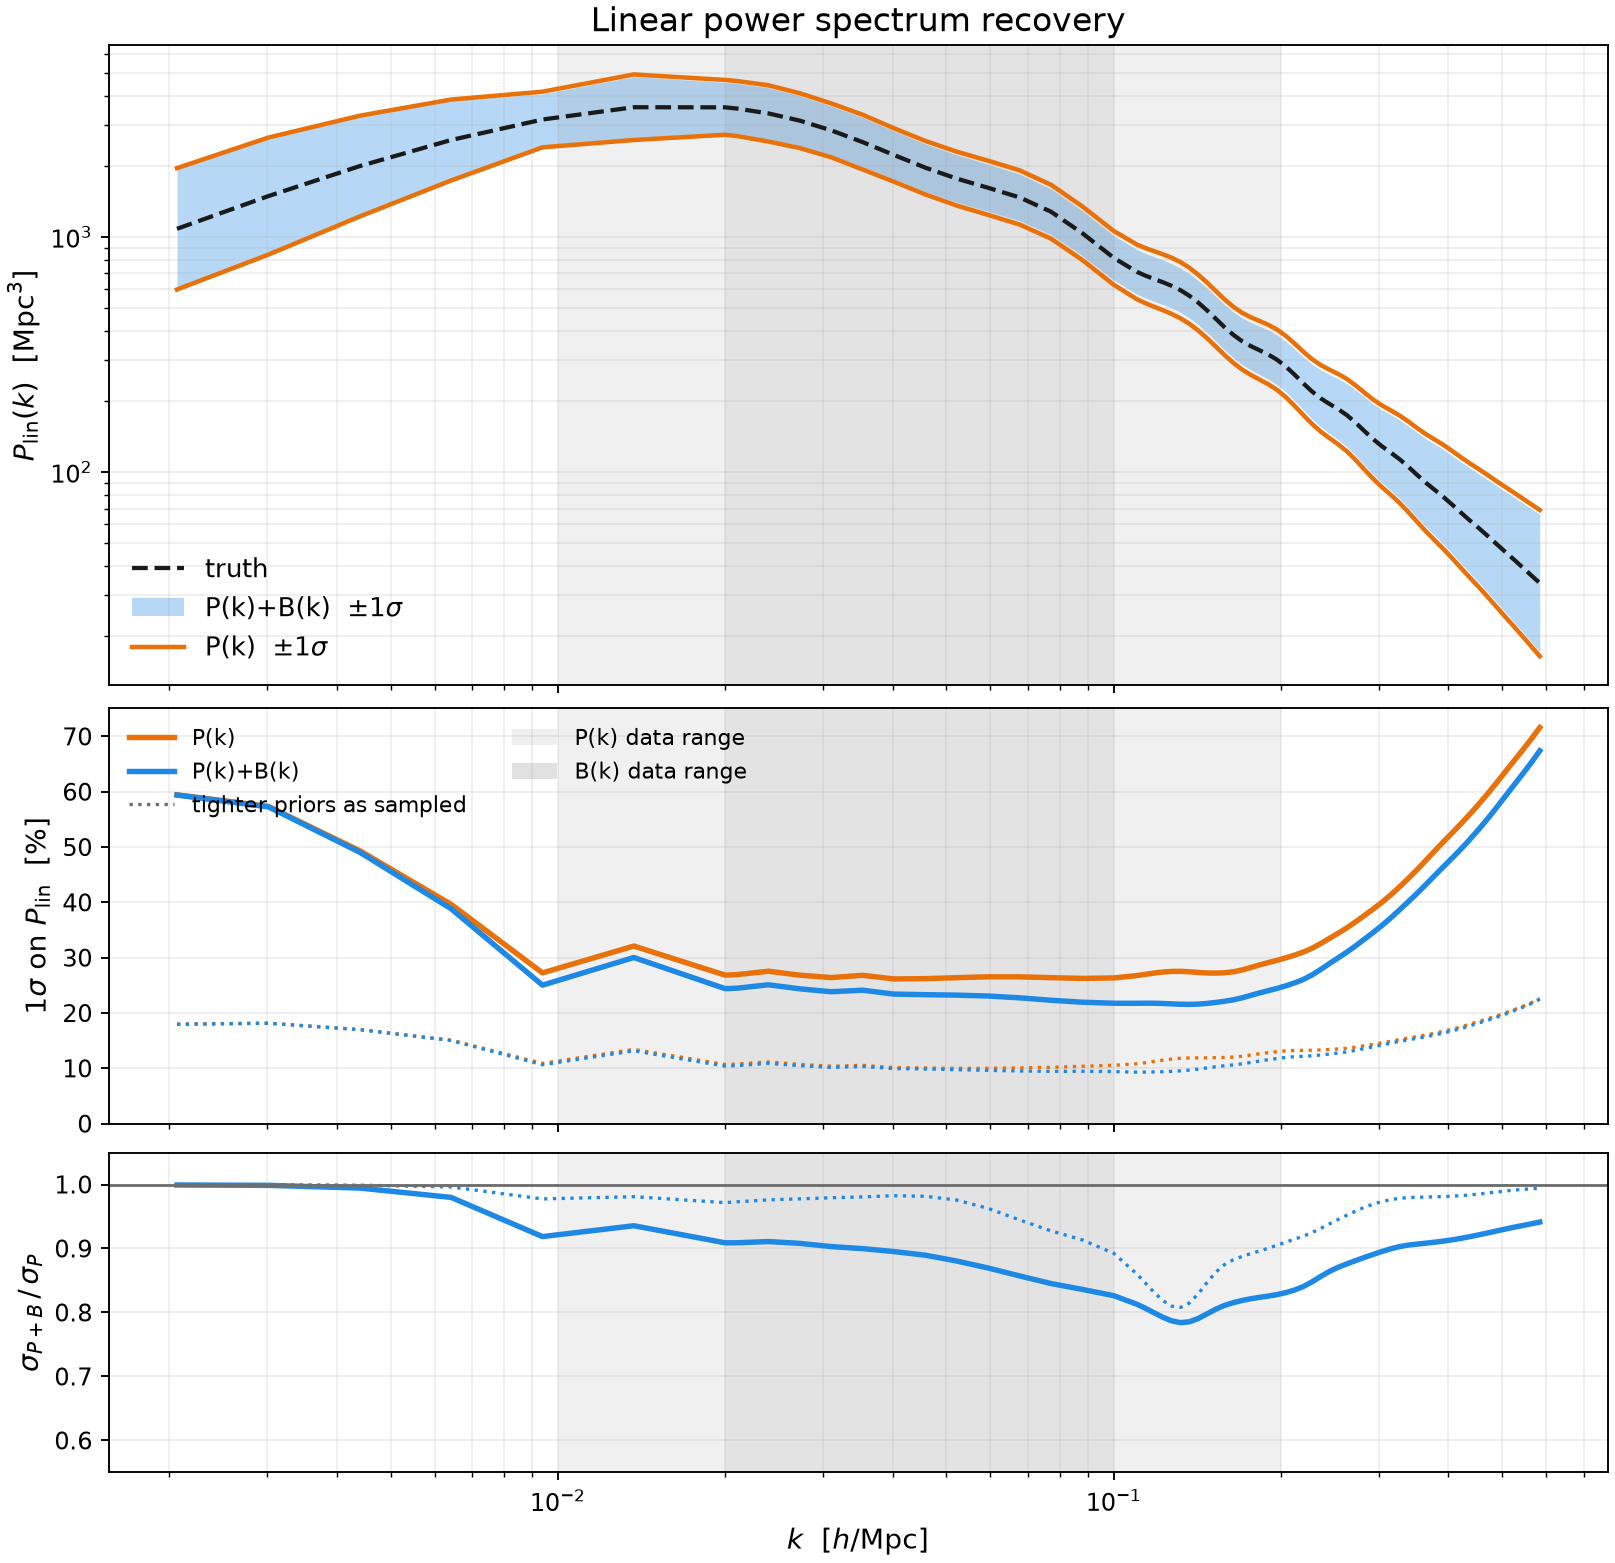

In [3]:
from IPython.display import Image, display
display(Image(filename='../../output/fisher_pb/meeting/fig_bands_pb.png', width=880))

## 5. Result 2 — the growth sector

At $z = 0.71$, everything else marginalized. **The bispectrum halves $\sigma(f)$** — 18.5% → 9.7% —
and the gain holds at every redshift except the sparsest bin. That is the headline: with a free
template, P(k) alone barely measures the growth rate, because the amplitude of the spectrum and
the linear bias are degenerate; the bispectrum breaks that degeneracy directly.

The $H$ and $D_A$ widths in this corner are *not* a measurement: the ruler direction $g_1$ contains
no amplitudes, so no template prior and no data can fix it, and those widths are set by the
$h_{\rm conv}$ and growth priors. The combinations that *are* measured — $D_M/r_d$, $D_H/r_d$,
$F_{\rm AP}$ — are the subject of notebook 09.

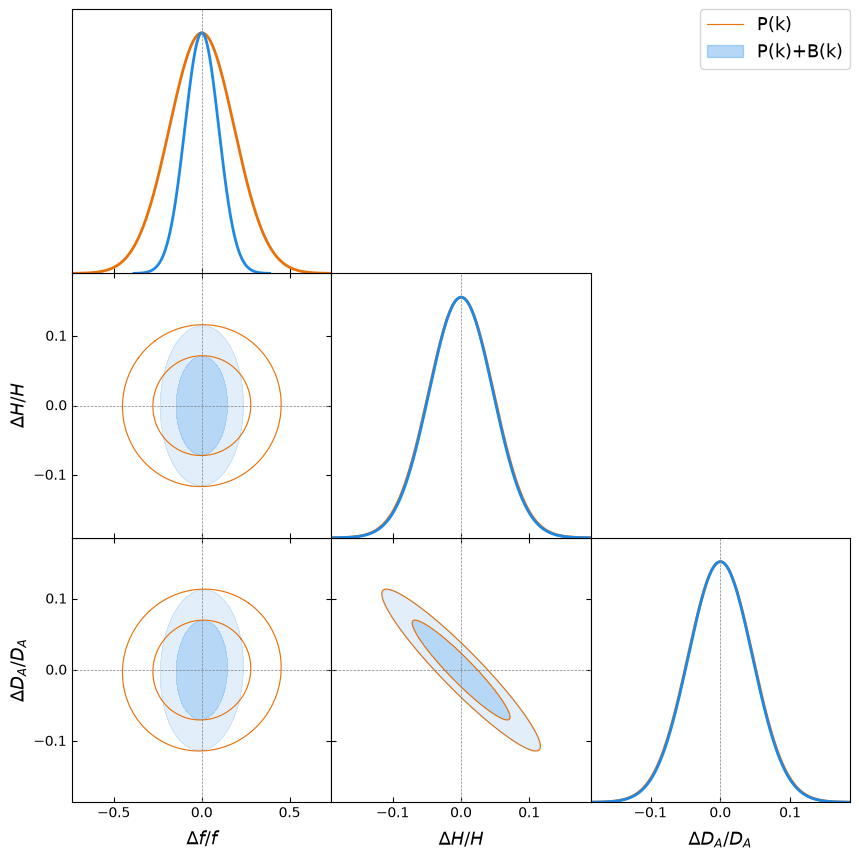

In [4]:
from IPython.display import Image, display
display(Image(filename='../../output/fisher_pb/meeting/fig_growth_corner.png', width=720))

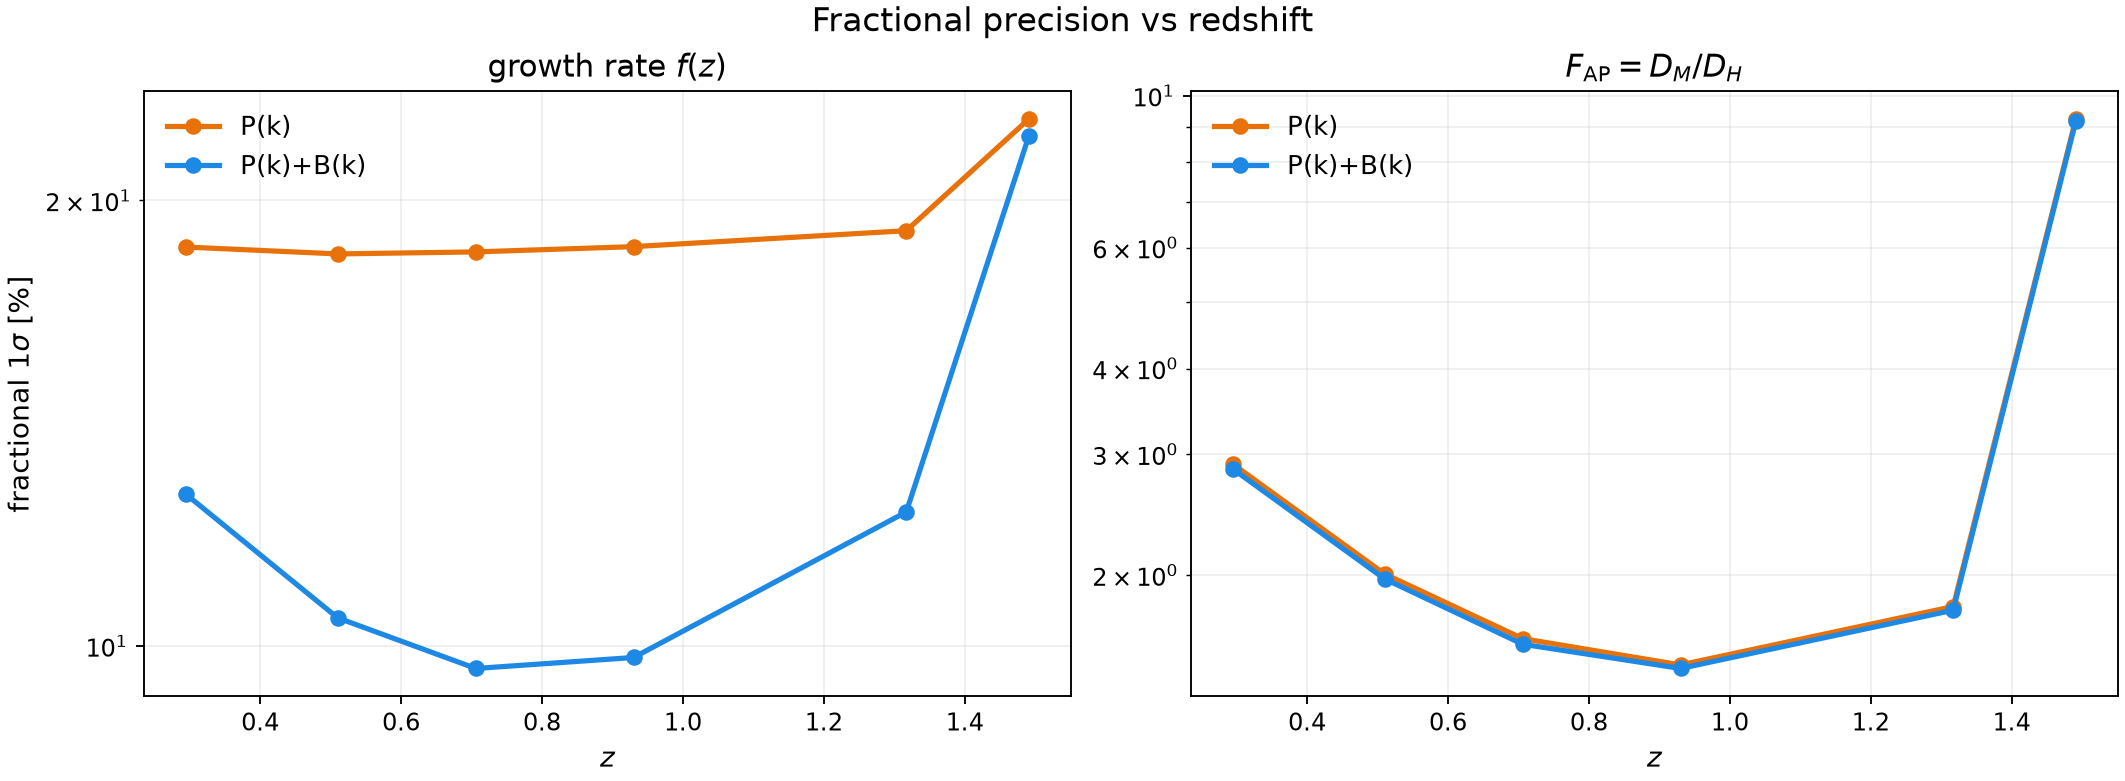

In [5]:
from IPython.display import Image, display
display(Image(filename='../../output/fisher_pb/meeting/fig_growth_vs_z.png', width=980))

## 6. Result 3 — $\Lambda$CDM recovery, direct vs through the model-independent likelihood

This is the check that the model-independent detour neither invents nor destroys information.
$\Lambda$CDM is fitted two ways:

* **direct** — the ordinary full-shape $\Lambda$CDM fit: three parameters, 80 template amplitudes
  and 25 growth parameters determined by them;
* **through the MI model** — the same data and the same likelihood, but routed through the
  model-independent parametrisation (60 spline nodes), then restricted to $\Lambda$CDM.

Two gates are printed above. First, the direct $\Lambda$CDM model vector is differentiated
*through the same likelihood call* and compared with the MI Jacobian composed with the cosmology
map: they agree to $1.4\times10^{-6}$, so the two routes are the same model, not two models that
happen to look alike. Second, the 60-node basis represents the $\Lambda$CDM template response to
1–2%. The resulting $\Lambda$CDM errors agree to 1–3% — nothing is added, nothing is lost.

**One caveat, and it matters for compressing a real chain.** The MI *prior* is not flat along the
$\Lambda$CDM directions: on its own, with no data at all, it corresponds to
$\sigma(\omega_{\rm cdm}) = 0.0035$ and $\sigma(\ln 10^{10}A_s) = 0.046$ — comparable to what the
data themselves deliver. A per-node width of 0.5 is loose for *one* node but tight for a coherent
shift of all sixty, which is exactly what a cosmological parameter produces. So compressing an MI
posterior onto $\Lambda$CDM **without dividing out that induced prior** tightens $\omega_{\rm cdm}$
by a factor 2 and $A_s$ by 2.5 artificially (third row of the table). The curves below use the
corrected route.

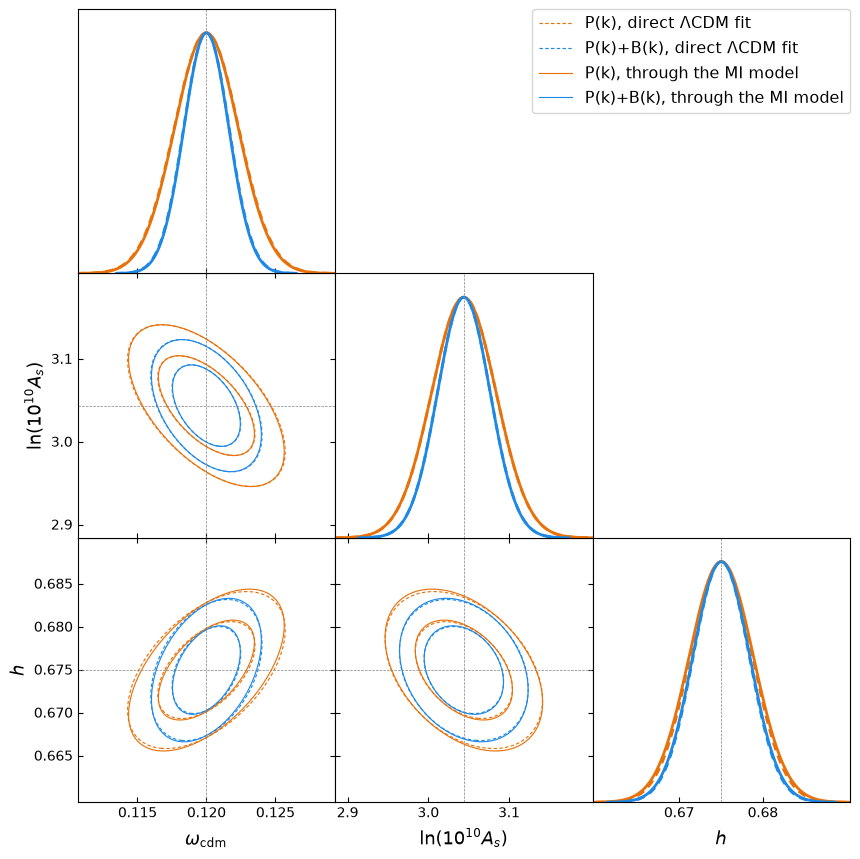

In [6]:
from IPython.display import Image, display
display(Image(filename='../../output/fisher_pb/meeting/fig_cosmo_pb.png', width=760))

## 7. The priors, and which of them is doing work

Every prior in the model, and what it is for:

| block | width | acts on | why it is there |
|---|---|---|---|
| $\sigma_{\ln a}$ | 0.5 | $\ln a$ at each of the 60 nodes | keep the sampler in a sane region |
| $\lambda$ | 200 | $\|D_2 \ln a\|^2$, second differences between nodes | keep $\ln a$ smooth — the loop emulator misbehaves on jagged input |
| $\sigma_{\ln g}$ | 0.3 | $\ln$ of every growth quantity ($f$, $H$, $D_A$, $D$-ratios) | keep them positive and $O(1)$ |
| $\sigma_{\ln h}$ | 0.05 | $\ln h_{\rm conv}$ | $h_{\rm conv}$ is *exactly* unconstrained by the data (the $g_1$ symmetry) |

None of them was meant to carry information. The cell below turns each one off and on in turn.

**The result is unambiguous: $\lambda$ is the block that matters, and $\sigma_{\ln a}$ does
essentially nothing to $\Lambda$CDM.** With $\lambda$ alone, $\sigma(\omega_{\rm cdm})$ goes from
0.0016 to 0.0010 and $\sigma(\ln 10^{10}A_s)$ from 0.0325 to 0.0139 — the entire effect. Turning
$\sigma_{\ln a}$ from 0.5 to 10 changes the $\Lambda$CDM errors not at all. The reason is that
$A_s$ is a *constant* shift of $\ln a$, which costs the smoothness penalty nothing directly, but
$\lambda$ pins the curvature of $\ln a$ in $\ln k$ and so breaks the degeneracy between the
template shape and the cosmological parameters.

$\sigma_{\ln a}$ is not innocent either, just in a different place: it sets much of the *reported*
P(k) band (section 4), which is why the band in that figure is shown for both settings.

**Recommended for the next chain: $\sigma_{\ln a} = 2$, $\lambda = 50$.** The node-to-node
roughness the prior still allows goes from 0.066 to 0.135 — still smooth, which was $\lambda$'s
actual job. The MI results barely move ($\sigma(f)$ 9.7% → 10.0%, $D_M/r_d$ with the phase prior
0.85% → 1.03%); the P(k) band widens to what the data actually constrain.

**Two warnings from the same audit.**

1. No practical $\lambda$ makes the induced $\Lambda$CDM prior negligible ($\lambda = 5$ still
   leaves $A_s$ at 0.76 of its data-only width, and $\lambda = 0$ allows a roughness of 5). So
   widening is not by itself a fix: an MI posterior compressed onto $\Lambda$CDM **must** divide
   out the induced prior. Done that way it matches the direct fit at any prior width, which is
   what section 6 shows.
2. $\lambda$ multiplies *unnormalized* second differences, so for a smooth function its strength
   scales as (node spacing)$^4$. The 16-node "BAO-rigid" basis of notebook 07 therefore carries a
   smoothness prior ~250× stronger than the same $\lambda$ at spacing 0.15. The phase prior of
   notebook 09 does not have this problem: it is stated directly as a fraction and always applied
   on the 60-node basis.

In [7]:
%run prior_decomposition_pb.py

Which prior does the work? A block-by-block decomposition, for LCDM and for the MI results.

The model-independent model carries four prior blocks (setups.COMMON, and mi_model.prior_prec_mat):

  s_lna  = 0.5    a Gaussian of this width on ln a at EACH of the 60 nodes
  lambda = 200    a penalty lambda * ||D2 ln a||^2 on second differences of ln a between nodes
  s_lng  = 0.3    a Gaussian of this width on ln of every growth quantity (f, H, D_A, D-ratios)
  s_lnh  = 0.05   a Gaussian of this width on ln h_conv

None of them is meant to carry information: s_lna and lambda exist to keep the sampler (and the
loop emulator, which misbehaves on jagged ln a) in a sane region, s_lng to keep the growth
parameters positive and O(1), s_lnh because h_conv is exactly unconstrained by the data.


1. THE INDUCED PRIOR ON LCDM, NO DATA AT ALL
                                        omega_cdm  ln(1e10 As)            h
  s_lna                                    0.0091       6.3601     398.4119
  lambda

  as sampled: 0.5 / 200                       0.1022       9.7%     1.94%            0.85%


  s_lna off (1e6)                             0.2883      10.1%     1.99%            0.90%


  lambda off (0)                              0.1547      10.1%     4.80%            1.14%


  s_lng off (1e6)                             0.1090      10.8%     1.99%            0.85%


...

   10.0    50 |       0.67      0.49      0.93 |   0.139 |   0.290    10.2%    3.12%    1.06%


   10.0    20 |       0.72      0.58      0.93 |   0.218 |   0.296    10.3%    3.93%    1.24%


   10.0     5 |       0.83      0.76      0.96 |   0.430 |   0.310    10.4%    4.84%    1.53%


   10.0     0 |       1.00      1.00      0.99 |  24.495 |   0.460    11.0%    5.85%    1.87%

  'LCDM sigma ratio to data-only' is the contamination: 1.00 = the prior adds nothing
  to LCDM, 0.42 = it halves the error bar out of nowhere. 'rough' is the node-to-node
  roughness the prior still allows (1 sigma on one second difference of ln a), which is
  what the smoothness penalty was for. 'band' is the fractional width of the recovered
  P_lin inside the data window: part of the current 0.10 is prior, not data.

5. A WARNING ABOUT lambda AND THE NODE SPACING
   lambda multiplies UNNORMALIZED second differences, D2 = a[i+1] - 2a[i] + a[i-1]. For a
   smooth function those scale as (node spacing)^2, so the same lambda is a much STRONGER
   prior on a coarse basis. Anything that changes node_spacing changes the prior too:

  spacing  nodes   roughness  equivalent lambda at 0.15
     0.15     60       0.066                        200
     0.25     36       0.066                       154


saved /capstor/store/cscs/swissai/a0158/areeves/pybird_model_independent/notebooks/fisher/../../output/fisher_pb/meeting/fig_prior_decomposition.png

RECOMMENDATION
  * lambda is the block that matters: with s_lna anywhere from 0.5 to 10 the LCDM errors are
    identical, while lambda alone accounts for the whole factor 2 on omega_cdm and 2.4 on A_s.
    s_lna is not doing harm to LCDM -- but it IS setting a large part of the reported P(k) band,
    so it should still be widened to report an honest band.
  * Recommended for the next chain: s_lna = 2, lambda = 50 (from 0.5 / 200). The node-to-node
    roughness the prior allows goes 0.066 -> 0.135, still smooth enough for the loop emulator,
    which is the job lambda was introduced for. The MI results barely move: sigma(f) 9.7 -> 10.0%,
    D_M/r_d with the phase prior 0.85 -> 1.03%. The reported P(k) band widens 0.10 -> 0.23, which
    is the point: that width was previously prior, not data.
  * No practical lambda makes the induced 

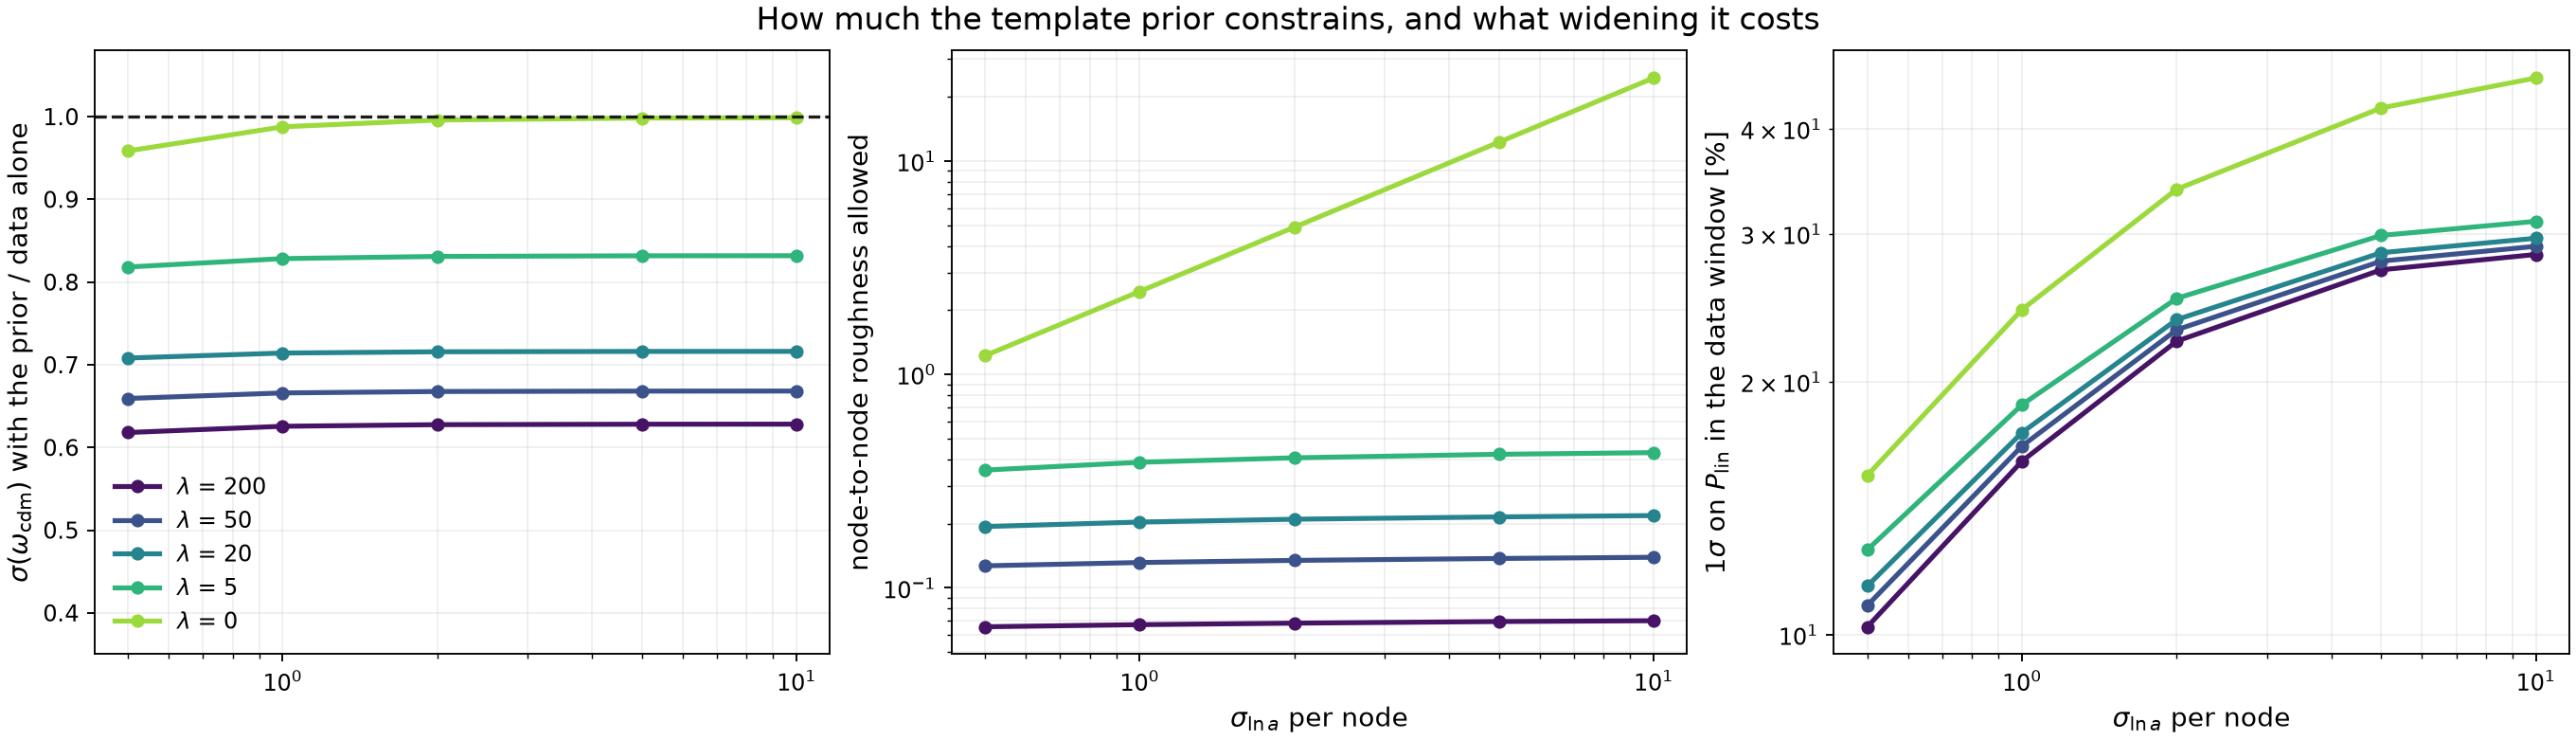

In [8]:
from IPython.display import Image, display
display(Image(filename='../../output/fisher_pb/meeting/fig_prior_decomposition.png', width=1150))

## Summary

| | P(k) | P(k)+B(k) |
|---|---|---|
| fractional $1\sigma$ on $P_{\rm lin}$ per node, in the data window | 27.4% | 23.1% |
| $\sigma(f)/f$ at $z=0.71$ | 18.5% | **9.7%** |
| $\sigma(F_{\rm AP})$ at $z=0.71$ | 1.62% | 1.59% |
| $\sigma(\omega_{\rm cdm})$ | 0.0023 | 0.0016 |
| $\sigma(\ln 10^{10}A_s)$ | 0.040 | 0.033 |
| $\sigma(h)$ | 0.0037 | 0.0034 |
| $\Lambda$CDM through the MI model / direct | 0.99–1.03 | 0.99–1.02 |

(The $P_{\rm lin}$ row uses the recommended wider priors; with the tighter priors run so far it
reads 11.3% / 10.2%, most of which is prior. Everything else is insensitive to the choice.)

The bispectrum's information goes almost entirely into the **growth rate and the amplitude**, not
into the geometry. That is expected: at tree level $B \propto P^2$, so it fixes the bias–amplitude
degeneracy, while the AP parameters come from the shape of the anisotropy, which P(k) already
carries.

**Caveats.** Tree-level bispectrum, Gaussian covariance, no window, zero P–B cross-covariance, a
noiseless mock at the fiducial, and a Fisher (precision, not accuracy — a bias test with a mock
generated at a shifted cosmology is still to do).